In [1]:
# UMAP projection of the JUMP-CP morphological profiles (MC, non-genotoxic
# Non-MC, and DMSO controls) - Methods 2.3.1, Figure 1.

import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Per-compound, per-source median profiles (int_ns_h preprocessing variant -
# see data/preprocess_JUMPCP.py), 748 Harmony-corrected features each.
JUMP_DIR = "../../data/processed/int_ns_h/"

# DATA LOADING

In [3]:
mc_jump_df = pd.read_csv(JUMP_DIR + "mc_jump_profiles.csv", index_col=[0, 1])
nomc_jump_df = pd.read_csv(JUMP_DIR + "nomc_genotox_jump_profiles.csv", index_col=[0, 1])
dmso_jump_df_median = pd.read_csv(JUMP_DIR + "dmso_jump_profiles.csv", index_col=[0, 1])

# UMAP - Data Visualization/Exploration

In [4]:
# UMAP is fit directly on the median morphological profiles (no scaling),
# combining MC, non-genotoxic Non-MC, and DMSO control profiles.
combined_jump_df = pd.concat([mc_jump_df, nomc_jump_df, dmso_jump_df_median])

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(combined_jump_df)

/home/achebouche/miniconda3/envs/dataproc/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


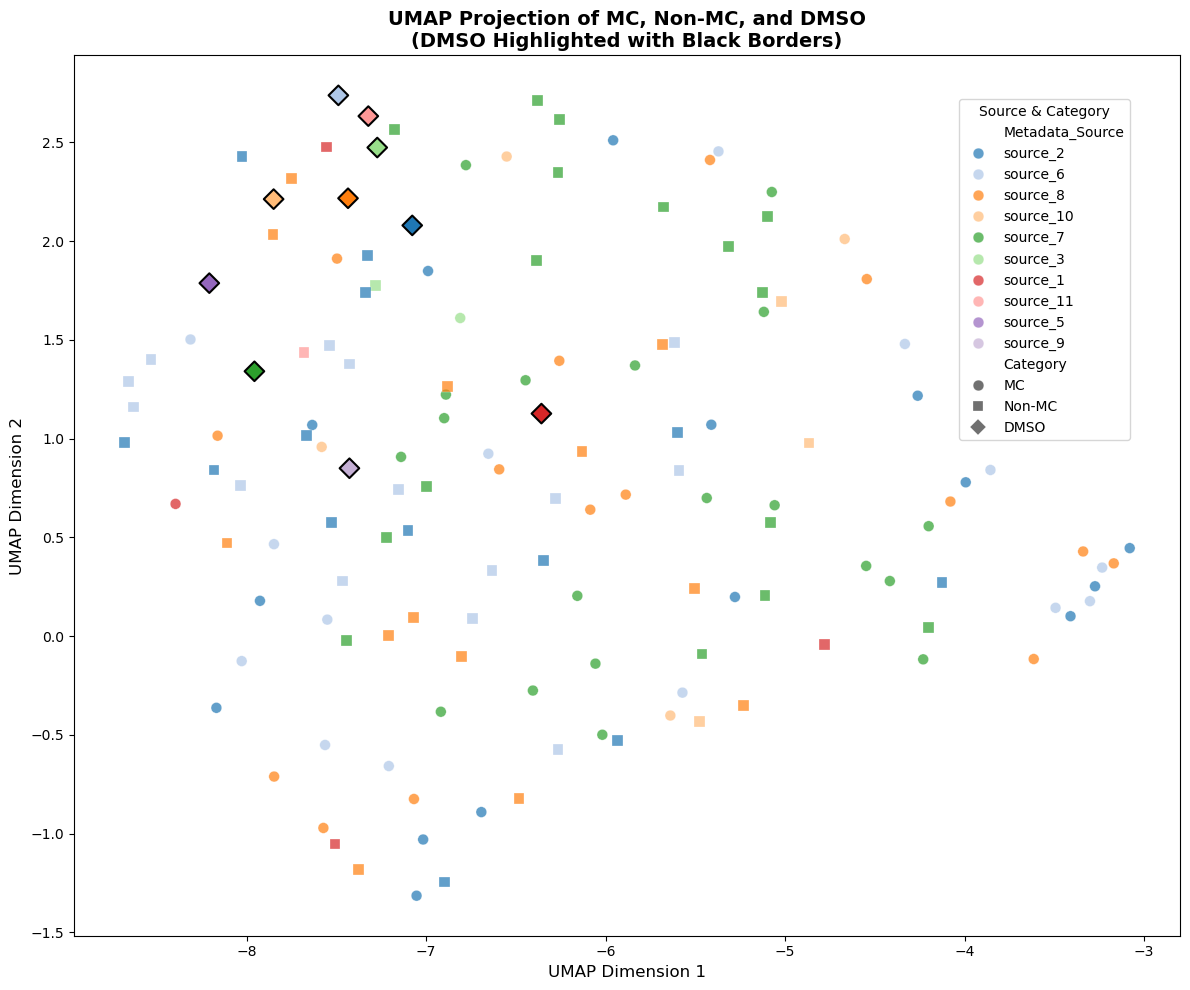

In [5]:
combined_index = combined_jump_df.index
categories = (
    ["MC"] * len(mc_jump_df)
    + ["Non-MC"] * len(nomc_jump_df)
    + ["DMSO"] * len(dmso_jump_df_median)
)
embedding_df = pd.DataFrame(
    {
        "UMAP1": embedding[:, 0],
        "UMAP2": embedding[:, 1],
        "Category": categories,
        "Metadata_Source": combined_index.get_level_values("Metadata_Source"),
        "JUMP_ID": combined_index.get_level_values("Metadata_JCP2022"),
    }
)

# Sort so DMSO renders last (on top) — MC=0, NOMC=1, DMSO=2
PLOT_ORDER = {"MC": 0, "Non-MC": 1, "DMSO": 2}
embedding_df = embedding_df.sort_values(
    "Category", key=lambda s: s.map(PLOT_ORDER)
).reset_index(drop=True)

unique_sources = embedding_df["Metadata_Source"].unique()
palette = dict(zip(unique_sources, sns.color_palette("tab20", len(unique_sources))))
markers = {"MC": "o", "Non-MC": "s", "DMSO": "D"}

fig, ax = plt.subplots(figsize=(12, 10))

sns.scatterplot(
    data=embedding_df,
    x="UMAP1",
    y="UMAP2",
    hue="Metadata_Source",
    style="Category",
    palette=palette,
    markers=markers,
    s=60,
    alpha=0.7,
    edgecolor="white",
    linewidth=0.3,
    ax=ax,
)

# Overlay DMSO with a black border so it stands out in dense regions
dmso_subset = embedding_df[embedding_df["Category"] == "DMSO"]
sns.scatterplot(
    data=dmso_subset,
    x="UMAP1",
    y="UMAP2",
    hue="Metadata_Source",
    marker=markers["DMSO"],
    palette=palette,
    s=100,
    edgecolor="black",
    linewidth=1.5,
    legend=False,
    ax=ax,
)

ax.set_xlabel("UMAP Dimension 1", fontsize=12)
ax.set_ylabel("UMAP Dimension 2", fontsize=12)
ax.set_title(
    "UMAP Projection of MC, Non-MC, and DMSO\n(DMSO Highlighted with Black Borders)",
    fontsize=14,
    weight="bold",
)
ax.legend(bbox_to_anchor=(0.8, 0.95), loc="upper left", borderaxespad=0, title="Source & Category")
plt.tight_layout()
plt.savefig("../../figures/UMAP_MC_NOMC_DMSO_Highlighted.png", dpi=600, bbox_inches="tight")
plt.show()

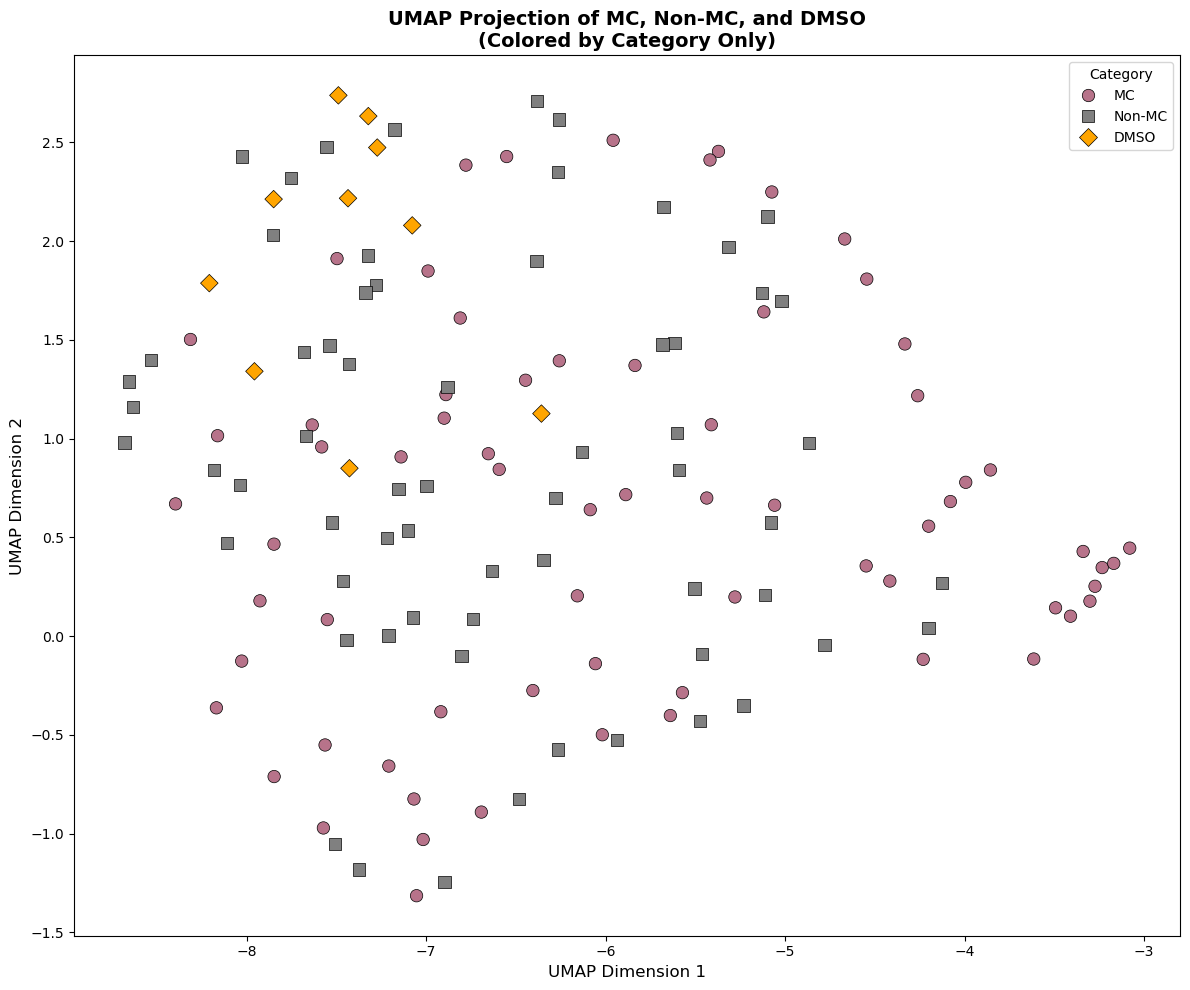

In [6]:
# UMAP visualization but only three color categories (MC, NOMC, DMSO) without source coloring
fig, ax = plt.subplots(figsize=(12, 10))
sns.scatterplot(
    data=embedding_df,
    x="UMAP1",
    y="UMAP2",
    hue="Category",
    style="Category",
    palette={"MC": "#B7738A", "Non-MC": "#808080", "DMSO": "#FFA500"},
    markers={"MC": "o", "Non-MC": "s", "DMSO": "D"},
    s=80,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
)
ax.set_xlabel("UMAP Dimension 1", fontsize=12)
ax.set_ylabel("UMAP Dimension 2", fontsize=12)
ax.set_title(
    "UMAP Projection of MC, Non-MC, and DMSO\n(Colored by Category Only)",
    fontsize=14,
    weight="bold",
)
ax.legend(title="Category")
plt.tight_layout()
plt.savefig("../../figures/UMAP_MC_NOMC_DMSO_ByCategory.png", dpi=600, bbox_inches="tight")
plt.show()
